# README


**Project Title: Spotify vs Youtube**  

**Tutorial section: TT6L**

**Group 5**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | 242UC244SR   | Chan Jia Yi                 | 25%          | 
| 2 | 242UC244QN   | Chew Jia Yi                 | 25%          | 
| 3 | 242UC244FZ   | Koay Yee Shuen              | 25%          | 
| 4 | 242UC244GL   | Ong Wan Ning                | 25%          | 

</div>

Note: Marks may vary among group members based on individual contributions. Ensure all members agree on the contribution percentages listed here.

**YouTube link:**  
Please note that the examiner will not notify you if your video link is unavailable, inaccessible, or incorrectly provided. It is the responsibility of the group to ensure that the video link is fully functional and accessible at the time of assessment. Failure to provide a valid and working link will result in a score of zero (0) marks for the presentation component.

**Dataset Title:**  
**Source & Link:** (e.g., Kaggle / UCI / Data.gov / Google Dataset Search — provide the dataset page URL)  
**Download instructions:** If the dataset requires sign-in (e.g., Kaggle), document the exact steps here      
**Brief Description (2–4 sentences):**   

**How to Run (if required, 1–3 steps):**  
  Instructions to run the notebook, including how to place the dataset files.    
  

## 1. Introduction & Problem Statement
<span style="background-color:yellow">- What is the main objective of this analysis?</span>

<span style="background-color:yellow">- What key questions/hypotheses will you explore?</span>

<span style="background-color:yellow">- Why is this dataset suitable for these questions?</span>

<span style="background-color:yellow">- All citations must be in listed in APA style.</span>

### Introduction

Digital music platforms such as Spotify and YouTube have transformed the entertainment industry by generating large amounts of user interaction and content performance data. Beyond basic popularity metrics such as streams and views, these platforms also provide measurable audio characteristics including danceability, energy, valence, tempo, and acousticness. These features create valuable opportunities for data-driven analysis.

Understanding how audio profiles relate to popularity can help artists, producers, and marketers make better strategic decisions. In addition, machine learning methods can be used to predict performance, identify hidden listener patterns, and classify high-performing songs.

Therefore, this project uses a Spotify and YouTube dataset from Kaggle to analyze the relationship between song features and popularity using multiple analytical techniques.

### Main Objective

The main objective of this analysis is to investigate how audio characteristics influence song popularity across Spotify and YouTube, and to apply data science techniques such as correlation analysis, prediction, clustering, and classification to uncover meaningful patterns in digital music performance.

### Key Questions / Hypotheses

1. Which audio features (danceability, energy, valence, etc.) are most strongly correlated with Spotify stream counts?
2. Do songs in this dataset achieve a significantly higher average consumption volume on Spotify (via streams) compared to YouTube (via video views)?
3. Can songs be grouped into distinct clusters based on their audio profile (e.g., high-energy vs. acoustic)?
4. Can we classify whether a song is a "viral hit" (top 25% in views + streams) based on its audio features?


## 2. Data Source & Understanding
- **Description:** Features/columns, size, time span, units
- **Limitations:** Coverage, missingness, sampling bias, known caveats


The dataset used in this project is the **Spotify and YouTube** dataset obtained from Kaggle. The dataset contains statistics for top songs from various Spotify artists and their corresponding YouTube video performance. It includes both Spotify audio features and YouTube engagement metrics, making it suitable for analyzing music popularity across digital entertainment platforms.

Dataset source: Kaggle - Spotify and YouTube data set by Salvatore Rastelli.

This dataset is suitable for this project because it provides:
- Spotify popularity information such as stream counts.
- YouTube performance metrics such as views, likes, and comments.
- Audio features such as danceability, energy, valence, acousticness, and tempo.
- Enough variables to support correlation analysis & ARM, hypothesis testing, clustering, and classification.

Reference:
Rastelli, S. (n.d.). *Spotify and YouTube dataset*. Kaggle. https://www.kaggle.com/datasets/salvatorerastelli/spotify-and-youtube

### 2.2 Dataset Size

The dataset contains 20718 rows and 28 columns.

Each row represents a song or track, while each column provides information about the track, artist, album, Spotify audio characteristics, and YouTube engagement metrics.

In [50]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display setting
pd.set_option("display.max_columns", None)

In [51]:
# Load the dataset ONCE only
df = pd.read_csv(r"Spotify_Youtube.csv")
df.head()


,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,222640.0,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,200173.0,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,215150.0,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,233867.0,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,340920.0,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [52]:
# Check dataset size
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 20718
Number of columns: 28


### 2.3 Features / Columns

The dataset contains several types of variables:

#### Identification Columns
- **Artist**: Name of the artist.
- **Track**: Name of the song.
- **Album**: Album name.
- **Album_type**: Type of album, such as album or single.

#### Spotify Audio Feature Columns
- **Danceability**: Indicates how suitable a song is for dancing. Values usually range from 0 to 1.
- **Energy**: Represents the intensity and activity level of a song. Values usually range from 0 to 1.
- **Key**: Musical key of the track.
- **Loudness**: Overall loudness of the song, usually measured in decibels.
- **Speechiness**: Measures the presence of spoken words in a track.
- **Acousticness**: Indicates how acoustic the song is.
- **Instrumentalness**: Predicts whether a track contains no vocals.
- **Liveness**: Detects the presence of a live audience in the recording.
- **Valence**: Measures the musical positivity or happiness of a song.
- **Tempo**: Speed of the song, measured in beats per minute.
- **Duration_ms**: Duration of the song in milliseconds.

#### Spotify Popularity Column
- **Stream**: Number of streams on Spotify.

#### YouTube Engagement Columns
- **Views**: Number of views on YouTube.
- **Likes**: Number of likes on YouTube.
- **Comments**: Number of comments on YouTube.
- **Channel**: YouTube channel name.
- **Title**: YouTube video title.

In [53]:
# Display all column names
df.columns.tolist()

['Unnamed: 0',
 'Artist',
 'Url_spotify',
 'Track',
 'Album',
 'Album_type',
 'Uri',
 'Danceability',
 'Energy',
 'Key',
 'Loudness',
 'Speechiness',
 'Acousticness',
 'Instrumentalness',
 'Liveness',
 'Valence',
 'Tempo',
 'Duration_ms',
 'Url_youtube',
 'Title',
 'Channel',
 'Views',
 'Likes',
 'Comments',
 'Description',
 'Licensed',
 'official_video',
 'Stream']

In [54]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  str    
 2   Url_spotify       20718 non-null  str    
 3   Track             20718 non-null  str    
 4   Album             20718 non-null  str    
 5   Album_type        20718 non-null  str    
 6   Uri               20718 non-null  str    
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float64
 17  Dura

In [55]:
# Summary statistics for numerical columns
df.describe()

,Unnamed: 0,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,20718.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,2.024800e+04,2.017700e+04,2.014900e+04,2.014200e+04
mean,10358.500000,0.619777,0.635250,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,9.393782e+07,6.633411e+05,2.751899e+04,1.359422e+08
std,5980.915774,0.165272,0.214147,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,2.746443e+08,1.789324e+06,1.932347e+05,2.441321e+08
min,0.000000,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,5179.250000,0.518000,0.507000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.826002e+06,2.158100e+04,5.090000e+02,1.767486e+07
50%,10358.500000,0.637000,0.666000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,15537.750000,0.740250,0.798000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,7.039975e+07,5.221480e+05,1.436000e+04,1.383581e+08
max,20717.000000,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


### 2.4 Missing Values

Missing values were checked for all columns. Columns with missing values may affect the accuracy of analysis and modeling. Therefore, missing values will be handled during the data cleaning stage.

For numerical columns such as streams, views, likes, comments, and audio features, missing values may be handled using median imputation or row removal depending on the amount of missing data.

For categorical columns such as artist, track, album, and channel, missing values may be filled with "Unknown" or removed if they are not useful for analysis.

In [56]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

Description         876
Stream              576
Comments            569
Likes               541
official_video      470
Licensed            470
Views               470
Channel             470
Title               470
Url_youtube         470
Valence               2
Duration_ms           2
Tempo                 2
Liveness              2
Instrumentalness      2
Acousticness          2
Speechiness           2
Loudness              2
Key                   2
Energy                2
Danceability          2
Artist                0
Uri                   0
Album_type            0
Album                 0
Track                 0
Url_spotify           0
Unnamed: 0            0
dtype: int64

In [57]:
# Check missing value percentage
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage.round(2)
})

missing_summary

,Missing Values,Missing Percentage (%)
Description,876,4.23
Stream,576,2.78
Comments,569,2.75
Likes,541,2.61
official_video,470,2.27
Licensed,470,2.27
Views,470,2.27
Channel,470,2.27
Title,470,2.27
Url_youtube,470,2.27


### 2.5 Duplicate Records

Duplicate records were checked to avoid repeated songs affecting the analysis. If duplicate rows are found, they will be removed during the data cleaning stage.

In [58]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### 2.6 Units of Measurement

The dataset uses different units depending on the type of variable:

- **Stream, Views, Likes, Comments**: Count values.
- **Danceability, Energy, Valence, Acousticness, Instrumentalness, Liveness, Speechiness**: Numerical scores, usually between 0 and 1.
- **Tempo**: Beats per minute (BPM).
- **Duration_ms**: Duration in milliseconds.
- **Loudness**: Decibels (dB).

These units are important because some machine learning methods such as clustering and hypothesis testing may require scaling or transformation before analysis.

In [59]:
# Select important numerical columns if they exist in the dataset
important_numeric_cols = [
    "Danceability", "Energy", "Valence", "Tempo", "Acousticness",
    "Instrumentalness", "Liveness", "Speechiness",
    "Stream", "Views", "Likes", "Comments"
]

existing_numeric_cols = [col for col in important_numeric_cols if col in df.columns]

df[existing_numeric_cols].describe()

,Danceability,Energy,Valence,Tempo,Acousticness,Instrumentalness,Liveness,Speechiness,Stream,Views,Likes,Comments
count,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.014200e+04,2.024800e+04,2.017700e+04,2.014900e+04
mean,0.619777,0.635250,0.529853,120.638340,0.291535,0.055962,0.193521,0.096456,1.359422e+08,9.393782e+07,6.633411e+05,2.751899e+04
std,0.165272,0.214147,0.245441,29.579018,0.286299,0.193262,0.168531,0.111960,2.441321e+08,2.746443e+08,1.789324e+06,1.932347e+05
min,0.000000,0.000020,0.000000,0.000000,0.000001,0.000000,0.014500,0.000000,6.574000e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.518000,0.507000,0.339000,97.002000,0.045200,0.000000,0.094100,0.035700,1.767486e+07,1.826002e+06,2.158100e+04,5.090000e+02
50%,0.637000,0.666000,0.537000,119.965000,0.193000,0.000002,0.125000,0.050500,4.968298e+07,1.450110e+07,1.244810e+05,3.277000e+03
75%,0.740250,0.798000,0.726250,139.935000,0.477250,0.000463,0.237000,0.103000,1.383581e+08,7.039975e+07,5.221480e+05,1.436000e+04
max,0.975000,1.000000,0.993000,243.372000,0.996000,1.000000,1.000000,0.964000,3.386520e+09,8.079649e+09,5.078865e+07,1.608314e+07


### 2.7 Time Span

This dataset does not mainly function as a time-series dataset. Instead, it is a cross-sectional dataset that captures song-level information and platform metrics at the time the dataset was collected.

If date-related columns are available, they can be used for limited trend analysis. However, since streams and views change over time, the dataset should be treated as a snapshot rather than real-time platform data.

In [60]:
# Check if the dataset contains any date-related columns
date_like_columns = [col for col in df.columns if "date" in col.lower() or "year" in col.lower()]

date_like_columns

[]

### 2.8 Dataset Limitations

Although this dataset is useful for analyzing music popularity, it has several limitations:

1. **Coverage Limitation**  
   The dataset does not include every song on Spotify or YouTube. It focuses on selected songs and artists, so the results may not represent the entire global music industry.

2. **Sampling Bias**  
   The dataset may be biased toward more popular or more accessible artists and songs. Less popular, local, or independent artists may be underrepresented.

3. **Missing Values**  
   Some columns may contain missing values, especially YouTube-related metrics or metadata. These missing values need to be handled carefully before analysis.

4. **Cross-Sectional Data**  
   The dataset is a snapshot of song performance at a certain point in time. Streams, views, likes, and comments can change over time, so the analysis does not represent real-time performance. Hence, this datset is not suitable for time series forecasting.

5. **Platform Differences**  
   Spotify streams and YouTube views are not exactly the same type of engagement. Spotify measures audio streaming, while YouTube includes video-based viewing. Therefore, direct comparison should be interpreted carefully.

6. **Popularity Does Not Mean Causation**  
   A strong relationship between audio features and popularity does not prove that the audio feature caused the song to become popular. Other factors such as marketing, artist fame, playlists, and social media trends may also influence popularity.

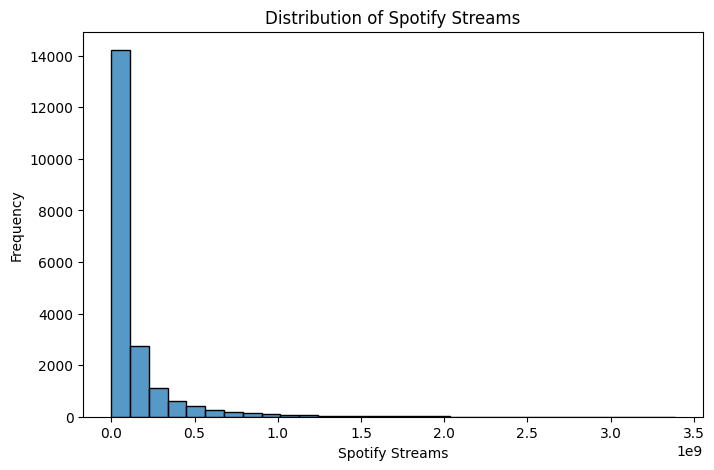

In [61]:
# Distribution of Spotify streams
if "Stream" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["Stream"].dropna(), bins=30)
    plt.title("Distribution of Spotify Streams")
    plt.xlabel("Spotify Streams")
    plt.ylabel("Frequency")
    plt.show()

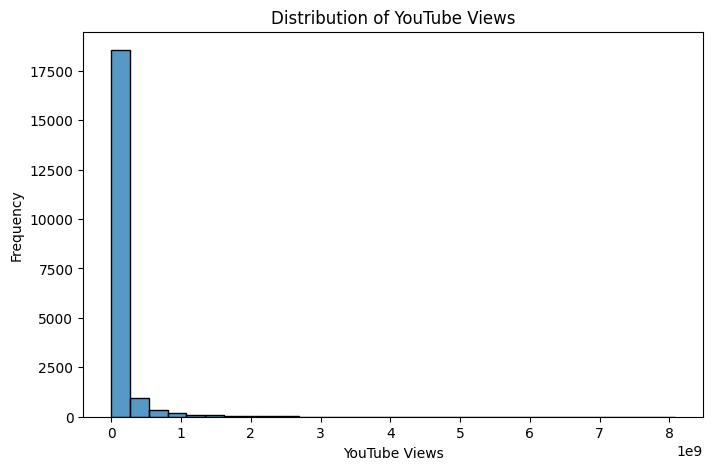

In [62]:
# Distribution of YouTube views
if "Views" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["Views"].dropna(), bins=30)
    plt.title("Distribution of YouTube Views")
    plt.xlabel("YouTube Views")
    plt.ylabel("Frequency")
    plt.show()

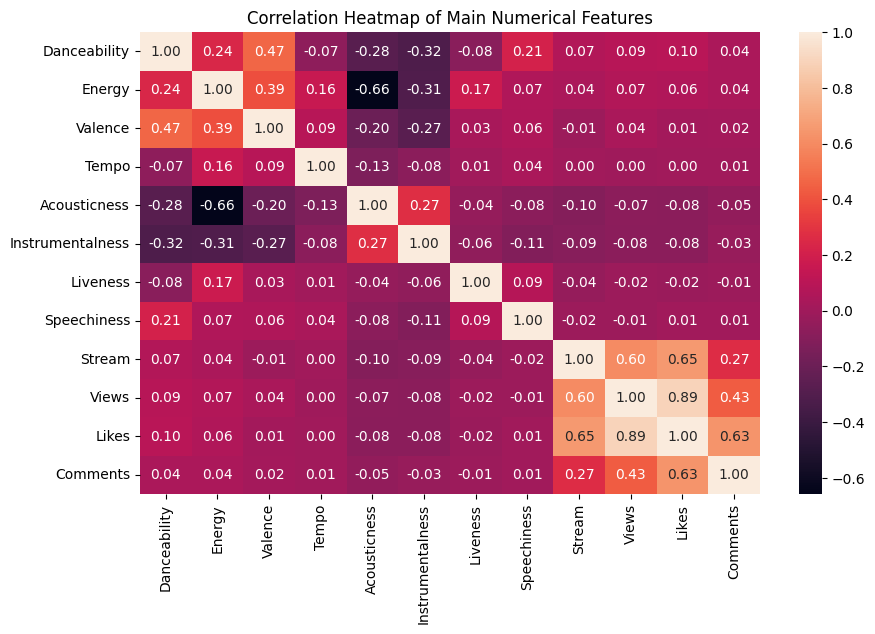

In [63]:
# Correlation heatmap for selected numerical columns
if len(existing_numeric_cols) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[existing_numeric_cols].corr(), annot=True, fmt=".2f")
    plt.title("Correlation Heatmap of Main Numerical Features")
    plt.show()

### 2.9 Summary

Overall, this dataset is appropriate for the project because it contains both Spotify audio features and YouTube engagement metrics. These variables support the four planned analytical questions: correlation analysis & ARM, hypothesis testing, prediction, clustering, and classification of viral hits.

However, the dataset has limitations such as missing values, possible sampling bias, and cross-platform measurement differences. These limitations will be considered during data cleaning, analysis, and interpretation.

## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [64]:
# Display the first 5 rows
df.head()

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
0,0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,222640.0,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,Official HD Video for Gorillaz' fantastic trac...,True,True,1.040235e+09
1,1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8.0,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,200173.0,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,The official video for Gorillaz - Rhinestone E...,True,True,3.100837e+08
2,2,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),single,spotify:track:64dLd6rVqDLtkXFYrEUHIU,0.695,0.923,1.0,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,215150.0,https://www.youtube.com/watch?v=qJa-VFwPpYA,Gorillaz - New Gold ft. Tame Impala & Bootie B...,Gorillaz,8435055.0,282142.0,7399.0,Gorillaz - New Gold ft. Tame Impala & Bootie B...,True,True,6.306347e+07
3,3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2.0,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,233867.0,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,Follow Gorillaz online:\nhttp://gorillaz.com \...,True,True,4.346636e+08
4,4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,340920.0,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,The official music video for Gorillaz - Clint ...,True,True,6.172597e+08


In [65]:
# Display the last 5 rows
df.tail()

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
20713,20713,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,JUST DANCE HARDSTYLE,JUST DANCE HARDSTYLE,single,spotify:track:0RtcKQGyI4hr8FgFH1TuYG,0.582,0.926,5.0,-6.344,0.0328,0.44800,0.0000,0.0839,0.6580,90.002,94667.0,https://www.youtube.com/watch?v=5SHmKFKlNqI,JUST DANCE HARDSTYLE,SICK LEGEND - Topic,71678.0,1113.0,0.0,Provided to YouTube by Routenote\n\nJUST DANCE...,True,True,9227144.0
20714,20714,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,SET FIRE TO THE RAIN HARDSTYLE,SET FIRE TO THE RAIN HARDSTYLE,single,spotify:track:3rHvPA8lUnPBkaLyPOc0VV,0.531,0.936,4.0,-1.786,0.1370,0.02800,0.0000,0.0923,0.6570,174.869,150857.0,https://www.youtube.com/watch?v=ocTH6KxllDQ,SET FIRE TO THE RAIN HARDSTYLE,SICK LEGEND - Topic,164741.0,2019.0,0.0,Provided to YouTube by Routenote\n\nSET FIRE T...,True,True,10898176.0
20715,20715,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,OUTSIDE HARDSTYLE SPED UP,OUTSIDE HARDSTYLE SPED UP,single,spotify:track:4jk00YxPtPbhvHJE9N4ddv,0.443,0.830,4.0,-4.679,0.0647,0.02430,0.0000,0.1540,0.4190,168.388,136842.0,https://www.youtube.com/watch?v=5wFhE-HY0hg,OUTSIDE HARDSTYLE SPED UP,SICK LEGEND - Topic,35646.0,329.0,0.0,Provided to YouTube by Routenote\n\nOUTSIDE HA...,True,True,6226110.0
20716,20716,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,ONLY GIRL HARDSTYLE,ONLY GIRL HARDSTYLE,single,spotify:track:5EyErbpsugWliX006eTDex,0.417,0.767,9.0,-4.004,0.4190,0.35600,0.0184,0.1080,0.5390,155.378,108387.0,https://www.youtube.com/watch?v=VMFLbFRNCn0,ONLY GIRL HARDSTYLE,SICK LEGEND - Topic,6533.0,88.0,0.0,Provided to YouTube by Routenote\n\nONLY GIRL ...,True,True,6873961.0
20717,20717,SICK LEGEND,https://open.spotify.com/artist/3EYY5FwDkHEYLw...,MISS YOU HARDSTYLE,MISS YOU HARDSTYLE,single,spotify:track:6lOn0jz1QpjcWeXo1oMm0k,0.498,0.938,6.0,-4.543,0.1070,0.00277,0.9110,0.1360,0.0787,160.067,181500.0,https://www.youtube.com/watch?v=zau0dckCFi0,MISS YOU HARDSTYLE,SICK LEGEND - Topic,158697.0,2484.0,0.0,Provided to YouTube by Routenote\n\nMISS YOU H...,True,True,5695584.0


In [66]:
# Display 5 random rows
df.sample(5, random_state=42)

,Unnamed: 0,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Url_youtube,Title,Channel,Views,Likes,Comments,Description,Licensed,official_video,Stream
16627,16627,Fiersa Besari,https://open.spotify.com/artist/06QVnTCdjs4jPK...,Seperti Kita Dulu,Berjalan Mundur,album,spotify:track:67OG3exhOS5t3K2X4tJaK5,0.580,0.430,1.0,-7.819,0.0284,0.665000,0.000000,0.1210,0.319,143.041,275691.0,https://www.youtube.com/watch?v=65wd-MKkB58,FIERSA BESARI - Seperti Kita Dulu (Official Ly...,Fiersa Besari,232802.0,6917.0,485.0,Musik dan lirik diciptakan oleh Fiersa Besari\...,False,True,1452542.0
7250,7250,Don Henley,https://open.spotify.com/artist/5dbuFbrHa1SJlQ...,Taking You Home,Soft Rock For Kids,compilation,spotify:track:2Ro4mKGAO5zgfwZmThAWhj,0.565,0.511,4.0,-7.134,0.0267,0.395000,0.000014,0.1100,0.108,72.350,331600.0,https://www.youtube.com/watch?v=MyzJlvt4VmU,Don Henley - Taking You Home (Video),Kacztv,205109.0,3227.0,227.0,"I do not own this song, it belongs to its righ...",False,False,8656408.0
14094,14094,Twenty One Pilots,https://open.spotify.com/artist/3YQKmKGau1PzlV...,Shy Away,Scaled And Icy,album,spotify:track:2nG54Y4a3sH9YpfxMolOyi,0.588,0.856,9.0,-5.242,0.0316,0.000818,0.073900,0.2380,0.635,96.966,175044.0,https://www.youtube.com/watch?v=3sO-Y1Zbft4,Twenty One Pilots - Shy Away (Official Video),twenty one pilots,49621794.0,914295.0,64550.0,Twenty One Pilots - Shy Away (Official Video)\...,True,True,154596684.0
8242,8242,will.i.am,https://open.spotify.com/artist/085pc2PYOi8bGK...,It’s My Birthday,It’s My Birthday,single,spotify:track:1pNcUexH7BdMFWFaxV3ltq,0.754,0.715,5.0,-4.434,0.0525,0.082200,0.000000,0.0891,0.405,100.001,252613.0,https://www.youtube.com/watch?v=JuM7hObGjWI,"will.i.am, Cody Wise - It's My Birthday (Offic...",williamVEVO,126711521.0,972628.0,46000.0,Music video by will.i.am & Cody Wise performin...,True,True,100587001.0
7228,7228,Armand Van Helden,https://open.spotify.com/artist/3cQA9WH8liZfej...,I Want Your Soul,Ghettoblaster,album,spotify:track:5WEYk2b7fdg0hl42Ts3f4I,0.754,0.876,10.0,-5.427,0.0696,0.004510,0.098800,0.1550,0.671,127.967,399547.0,https://www.youtube.com/watch?v=atYZVGL2iCQ,Armand Van Helden - I Want Your Soul,mushroomvideos,4039442.0,25412.0,735.0,Taken from the album 'Ghettoblaster'\n\nYou ca...,False,False,18175143.0


In [67]:
# Check number of rows and columns
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (20718, 28)
Number of rows: 20718
Number of columns: 28


The dataset contains rows representing songs/tracks and columns representing song information, Spotify audio features, and YouTube engagement metrics.

In [68]:
# Display all column names
df.columns.tolist()

['Unnamed: 0',
 'Artist',
 'Url_spotify',
 'Track',
 'Album',
 'Album_type',
 'Uri',
 'Danceability',
 'Energy',
 'Key',
 'Loudness',
 'Speechiness',
 'Acousticness',
 'Instrumentalness',
 'Liveness',
 'Valence',
 'Tempo',
 'Duration_ms',
 'Url_youtube',
 'Title',
 'Channel',
 'Views',
 'Likes',
 'Comments',
 'Description',
 'Licensed',
 'official_video',
 'Stream']

In [69]:
# Check data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20718 entries, 0 to 20717
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        20718 non-null  int64  
 1   Artist            20718 non-null  str    
 2   Url_spotify       20718 non-null  str    
 3   Track             20718 non-null  str    
 4   Album             20718 non-null  str    
 5   Album_type        20718 non-null  str    
 6   Uri               20718 non-null  str    
 7   Danceability      20716 non-null  float64
 8   Energy            20716 non-null  float64
 9   Key               20716 non-null  float64
 10  Loudness          20716 non-null  float64
 11  Speechiness       20716 non-null  float64
 12  Acousticness      20716 non-null  float64
 13  Instrumentalness  20716 non-null  float64
 14  Liveness          20716 non-null  float64
 15  Valence           20716 non-null  float64
 16  Tempo             20716 non-null  float64
 17  Dura

The `info()` output helps identify the data type of each column and whether there are missing values. This is useful before data cleaning because numerical columns should be stored as numerical data types, while text-based columns should be stored as object or string types.

In [70]:
# Summary statistics for numerical columns
df.describe()

,Unnamed: 0,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Views,Likes,Comments,Stream
count,20718.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.071600e+04,2.024800e+04,2.017700e+04,2.014900e+04,2.014200e+04
mean,10358.500000,0.619777,0.635250,5.300348,-7.671680,0.096456,0.291535,0.055962,0.193521,0.529853,120.638340,2.247176e+05,9.393782e+07,6.633411e+05,2.751899e+04,1.359422e+08
std,5980.915774,0.165272,0.214147,3.576449,4.632749,0.111960,0.286299,0.193262,0.168531,0.245441,29.579018,1.247905e+05,2.746443e+08,1.789324e+06,1.932347e+05,2.441321e+08
min,0.000000,0.000000,0.000020,0.000000,-46.251000,0.000000,0.000001,0.000000,0.014500,0.000000,0.000000,3.098500e+04,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,5179.250000,0.518000,0.507000,2.000000,-8.858000,0.035700,0.045200,0.000000,0.094100,0.339000,97.002000,1.800095e+05,1.826002e+06,2.158100e+04,5.090000e+02,1.767486e+07
50%,10358.500000,0.637000,0.666000,5.000000,-6.536000,0.050500,0.193000,0.000002,0.125000,0.537000,119.965000,2.132845e+05,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,15537.750000,0.740250,0.798000,8.000000,-4.931000,0.103000,0.477250,0.000463,0.237000,0.726250,139.935000,2.524430e+05,7.039975e+07,5.221480e+05,1.436000e+04,1.383581e+08
max,20717.000000,0.975000,1.000000,11.000000,0.920000,0.964000,0.996000,1.000000,1.000000,0.993000,243.372000,4.676058e+06,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09


In [71]:
# Summary statistics for categorical columns
df.describe(include="object")

C:\Users\Shuen\AppData\Local\Temp\ipykernel_21780\1817281860.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Artist,Url_spotify,Track,Album,Album_type,Uri,Url_youtube,Title,Channel,Description,Licensed,official_video
count,20718,20718,20718,20718,20718,20718,20248,20248,20248,19842,20248,20248
unique,2079,2079,17841,11937,3,18862,18154,18146,6714,17395,2,2
top,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,El Ultimo Adiós - Varios Artistas Version,Greatest Hits,album,spotify:track:0tzixmHNQfE6S6SirSToxW,https://www.youtube.com/watch?v=GqOvxbFLwjY,Color Esperanza 2020 - Various Artists (Offici...,T-Series,,True,True
freq,10,10,24,30,14926,24,18,18,238,114,14140,15723


The numerical summary shows the count, mean, standard deviation, minimum, maximum, and quartile values. This helps identify unusual values and possible outliers.

The categorical summary shows the number of unique values, the most frequent value, and its frequency.

In [72]:
# Check missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

Description         876
Stream              576
Comments            569
Likes               541
official_video      470
Licensed            470
Views               470
Channel             470
Title               470
Url_youtube         470
Valence               2
Duration_ms           2
Tempo                 2
Liveness              2
Instrumentalness      2
Acousticness          2
Speechiness           2
Loudness              2
Key                   2
Energy                2
Danceability          2
Artist                0
Uri                   0
Album_type            0
Album                 0
Track                 0
Url_spotify           0
Unnamed: 0            0
dtype: int64

In [73]:
# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage.round(2)
})

missing_summary

,Missing Values,Missing Percentage (%)
Description,876,4.23
Stream,576,2.78
Comments,569,2.75
Likes,541,2.61
official_video,470,2.27
Licensed,470,2.27
Views,470,2.27
Channel,470,2.27
Title,470,2.27
Url_youtube,470,2.27


Missing values are checked because they may affect the accuracy of analysis and machine learning models. Columns with missing values will be handled in the data cleaning and preprocessing section.

In [74]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


Duplicate rows are checked because repeated records may affect the accuracy of the analysis. If duplicates are found, they will be removed during data cleaning.

In [75]:
# Check unique values for selected categorical columns
categorical_cols = ["Artist", "Track", "Album", "Album_type"]

for col in categorical_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")

Artist: 2079 unique values
Track: 17841 unique values
Album: 11937 unique values
Album_type: 3 unique values


In [76]:
# Check important numerical columns
important_numeric_cols = [
    "Danceability", "Energy", "Valence", "Tempo", "Acousticness",
    "Instrumentalness", "Liveness", "Speechiness",
    "Stream", "Views", "Likes", "Comments"
]

existing_numeric_cols = [col for col in important_numeric_cols if col in df.columns]

df[existing_numeric_cols].describe()

,Danceability,Energy,Valence,Tempo,Acousticness,Instrumentalness,Liveness,Speechiness,Stream,Views,Likes,Comments
count,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,20716.000000,2.014200e+04,2.024800e+04,2.017700e+04,2.014900e+04
mean,0.619777,0.635250,0.529853,120.638340,0.291535,0.055962,0.193521,0.096456,1.359422e+08,9.393782e+07,6.633411e+05,2.751899e+04
std,0.165272,0.214147,0.245441,29.579018,0.286299,0.193262,0.168531,0.111960,2.441321e+08,2.746443e+08,1.789324e+06,1.932347e+05
min,0.000000,0.000020,0.000000,0.000000,0.000001,0.000000,0.014500,0.000000,6.574000e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.518000,0.507000,0.339000,97.002000,0.045200,0.000000,0.094100,0.035700,1.767486e+07,1.826002e+06,2.158100e+04,5.090000e+02
50%,0.637000,0.666000,0.537000,119.965000,0.193000,0.000002,0.125000,0.050500,4.968298e+07,1.450110e+07,1.244810e+05,3.277000e+03
75%,0.740250,0.798000,0.726250,139.935000,0.477250,0.000463,0.237000,0.103000,1.383581e+08,7.039975e+07,5.221480e+05,1.436000e+04
max,0.975000,1.000000,0.993000,243.372000,0.996000,1.000000,1.000000,0.964000,3.386520e+09,8.079649e+09,5.078865e+07,1.608314e+07


In [77]:
# Check zero or negative values in important numerical columns
for col in existing_numeric_cols:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    
    print(f"{col}:")
    print(f"  Zero values: {zero_count}")
    print(f"  Negative values: {negative_count}")

Danceability:
  Zero values: 17
  Negative values: 0
Energy:
  Zero values: 0
  Negative values: 0
Valence:
  Zero values: 26
  Negative values: 0
Tempo:
  Zero values: 17
  Negative values: 0
Acousticness:
  Zero values: 0
  Negative values: 0
Instrumentalness:
  Zero values: 9391
  Negative values: 0
Liveness:
  Zero values: 0
  Negative values: 0
Speechiness:
  Zero values: 17
  Negative values: 0
Stream:
  Zero values: 0
  Negative values: 0
Views:
  Zero values: 1
  Negative values: 0
Likes:
  Zero values: 18
  Negative values: 0
Comments:
  Zero values: 499
  Negative values: 0


Zero and negative values are checked to identify possible data quality issues. For example, negative values are usually not expected for streams, views, likes, or comments.

In [78]:
# Check memory usage
df.memory_usage(deep=True)

Index                    132
Unnamed: 0            165744
Artist               1283650
Url_spotify          2133954
Track                1510307
Album                1520142
Album_type           1128504
Uri                  1761030
Danceability          165744
Energy                165744
Key                   165744
Loudness              165744
Speechiness           165744
Acousticness          165744
Instrumentalness      165744
Liveness              165744
Valence               165744
Tempo                 165744
Duration_ms           165744
Url_youtube          1877856
Title                2149686
Channel              1293040
Views                 165744
Likes                 165744
Comments              165744
Description         46772063
Licensed              743968
official_video        743968
Stream                165744
dtype: int64

In [79]:
print("Initial Data Check Summary")
print("--------------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
print("Numerical columns:", df.select_dtypes(include=["int64", "float64"]).shape[1])
print("Categorical columns:", df.select_dtypes(include=["object"]).shape[1])

Initial Data Check Summary
--------------------------
Rows: 20718
Columns: 28
Duplicate rows: 0
Total missing values: 5404
Numerical columns: 16
Categorical columns: 12


C:\Users\Shuen\AppData\Local\Temp\ipykernel_21780\1559921235.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:", df.select_dtypes(include=["object"]).shape[1])


### Summary of Initial Data Checks

The initial data checks provide a general understanding of the dataset before cleaning. The dataset structure, column names, data types, missing values, duplicates, and basic numerical summaries were inspected.

Based on these checks, the next step is to clean and preprocess the dataset by handling missing values, removing duplicates if necessary, correcting data types, and preparing the data for exploratory analysis and modeling.

## 4. Data Cleaning & Preprocessing
- Handle missing values (strategy and justification)
- Fix types (dates, categoricals, numerics)
- Remove/flag outliers
- Feature engineering (document purpose)
- Keep transformations transparent and reproducible


### 4.1 Remove Non-Informative Column

All cleaning below is performed on 'df', the single DataFrame loaded once in Section 2 ('df = pd.read_csv(...)' in cell above). No file is re-read from this point on; every step below transforms 'df' in memory, in line with the project's strict single-load rule.

'Unnamed: 0' is a row index left over from the CSV report. It carries no analytical information, so it is dropped first.


In [80]:
# Work on a single cleaned copy derived from the in-memory df (no re-reading the file)
df_clean = df.drop(columns=['Unnamed: 0'])
print("Shape after removing index column:", df_clean.shape)

Shape after removing index column: (20718, 27)


### 4.2 Handle Missing Values — Part 1: Structural Drops

Missingness in this dataset has more than one cause, so each group of columns is handled according to why it is missing rather than applying one blanket rule:

| Missing columns | Rows affected | Likely cause | Strategy |
|---|---|---|---|
| 11 Spotify audio features (`Danceability` ... `Duration_ms`) | 2 | Spotify API returned no audio analysis for these 2 tracks | **Drop rows** — every analytical question in this project relies on audio features; the loss is 0.01% of the data |
| `Url_youtube`, `Title`, `Channel`, `Views`, `Licensed`, `official_video` | 469 | Song has no matched YouTube video in the scrape | **Drop rows** — our questions compare Spotify audio features against YouTube engagement, so a row with no YouTube data is unusable for them |
| `Likes`, `Comments`, `Stream` (remaining, after duplicates are resolved in 4.3) | small % | Video matched, but the specific count is unavailable (e.g. likes/comments disabled) | **Impute with median** — handled in Section 4.4, after deduplication |
| `Description` | several hundred | Free-text field, not used in any of our four analytical questions | **Column dropped** — handled in Section 4.4 |

We start with the two unconditional drops below.


In [81]:
# Drop the 2 rows that have NO spotify audio features at all
audio_cols = ["Danceability", "Energy", "Key", "Loudness", "Speechiness", "Acousticness", "Instrumentalness", "Liveness", "Valence", "Tempo", "Duration_ms"]

mask_audio_missing = df_clean[audio_cols].isnull().all(axis=1)
print("Rows with no Spotify audio features at all:", mask_audio_missing.sum())

df_clean = df_clean[~mask_audio_missing].copy()
print("Shape after dropping:", df_clean.shape)

Rows with no Spotify audio features at all: 2
Shape after dropping: (20716, 27)


In [82]:
# Drop rows with no matched youtube video (Url_youtube is null)
mask_no_youtube = df_clean['Url_youtube'].isnull()
print("Rows with no matched YouTube video:", mask_no_youtube.sum())

df_clean = df_clean[~mask_no_youtube].copy()
print("Shape after dropping:", df_clean.shape)

Rows with no matched YouTube video: 469
Shape after dropping: (20247, 27)


### 4.3 Resolve Duplicate Records

`df.duplicated()` showed 0 fully identical rows (checked in Section 3), but that check misses a real duplication issue specific to this dataset: many rows share the same Spotify `Uri` because the **same song is credited separately to each collaborating artist** (e.g. a duet appears once under Artist A and once under Artist B, with the same YouTube video and almost the same view count, recorded at slightly different scrape times).

If left as-is, these near-identical rows would double- or triple-count a single song's popularity in any song-level statistic (correlation & ARM, hypothesis testing, clustering). We resolve this by keeping **one row per unique `Uri`** — the row with the highest `Views`, since that is the most complete/representative observation for that song.

*Trade-off we are documenting:* this discards the "multiple artist credit" information. If a future analysis specifically needed artist-level credit-sharing, this decision would need to be revisited — but for this project's four questions (which are song-level), it is appropriate.


In [83]:
# Inspect the duplicate Uri pattern before fixing it
dup_uri_count = df_clean.duplicated(subset='Uri').sum()
print("Rows sharing a Spotify Uri with another row:", dup_uri_count)

# Example: show one group of rows that share a Uri (same song, multiple artist credits)
example_uri = df_clean[df_clean.duplicated(subset='Uri', keep=False)].sort_values('Uri')['Uri'].iloc[0]
df_clean[df_clean['Uri'] == example_uri][['Artist', 'Track', 'Album', 'Views', 'Stream']]

Rows sharing a Spotify Uri with another row: 1759


,Artist,Track,Album,Views,Stream
12829,Chris Young,Famous Friends,Famous Friends,19838389.0,125989578.0
17542,Kane Brown,Famous Friends,Famous Friends,19838446.0,125989578.0


In [84]:
# Keep one row per unique Uri: the row with the highest Views
before_dedup = df_clean.shape[0]

df_clean = (df_clean.sort_values('Views', ascending = False)
            .drop_duplicates(subset='Uri', keep='first')
            .sort_index())

print(f"Removed {before_dedup - df_clean.shape[0]} duplicate rows (same song, multiple artist credits)")
print("Shape after deduplication:", df_clean.shape)

Removed 1759 duplicate rows (same song, multiple artist credits)
Shape after deduplication: (18488, 27)


### 4.4 Handle Missing Values — Part 2: Impute Remaining Values

With duplicates resolved, we check what is still missing in `Likes`, `Comments`, and `Stream`. These are a small share of the remaining rows, and all three columns are heavily right-skewed (a few viral songs dominate the scale), so the **median** is used as a robust fill value that won't be distorted by extreme outliers.

`Description` is dropped entirely rather than cleaned — it is free text and is not used in any of our four analytical questions.


In [85]:
# Impute remaining missing engagement counts with the column median
for col in ['Likes', 'Comments', 'Stream']:
    n_missing = df_clean[col].isnull().sum()
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: imputed {n_missing} missing values with median = {median_val:,.0f}")

# Drop the unused free-text Description column
n_desc_missing = df_clean['Description'].isnull().sum()
df_clean = df_clean.drop(columns = ['Description'])
print(f"\nDropped 'Description' column ({n_desc_missing} missing, unused free text)")

print("\nShape so far:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())

Likes: imputed 68 missing values with median = 118,732
Comments: imputed 95 missing values with median = 3,158
Stream: imputed 531 missing values with median = 48,762,715

Dropped 'Description' column (382 missing, unused free text)

Shape so far: (18488, 26)
Remaining missing values: 0


### 4.5 Fix Data Types

A few columns are stored with the wrong dtype for what they represent:
- `Key` is a musical pitch class (0–11), stored as `float64` — cast to nullable integer.
- `Licensed`, `official_video` are true/false flags, stored as generic `object` — cast to `bool`.
- `Album_type` (`album` / `single` / `compilation`) is a fixed set of categories — cast to `category` for memory efficiency and to signal it is categorical for later modeling/encoding.


In [86]:
df_clean['Key'] = df_clean['Key'].astype('Int64')
df_clean['Licensed'] = df_clean['Licensed'].astype(bool)
df_clean['official_video'] = df_clean['official_video'].astype(bool)
df_clean['Album_type'] = df_clean['Album_type'].astype('category')

df_clean[['Key', 'Licensed', 'official_video', 'Album_type']].dtypes

Key                  Int64
Licensed              bool
official_video        bool
Album_type        category
dtype: object

### 4.6 Fix Invalid Values

Section 3 flagged `Tempo == 0` as a data quality concern — a song cannot genuinely have 0 beats per minute, so these are encoding errors rather than real measurements. They are treated as missing and imputed with the column median, the same robust strategy used for the engagement columns in 4.4.


In [87]:
# Treat Tempo == 0 as invalid, missing values, impute with median
n_invalid_tempo = (df_clean['Tempo'] == 0).sum()
print("Invalid Tempo (0 BPM) values found:", n_invalid_tempo)

df_clean['Tempo'] = df_clean['Tempo'].replace(0, np.nan)
tempo_median = df_clean['Tempo'].median()
df_clean['Tempo'] = df_clean['Tempo'].fillna(tempo_median)

print(f"Replaced with median tempo = {tempo_median:.2f} BPM")

Invalid Tempo (0 BPM) values found: 13
Replaced with median tempo = 119.98 BPM


### 4.7 Feature Engineering

New columns are derived from the cleaned data to directly support the four locked-in analytical questions:
- `duration_min` — track length in minutes (more interpretable than milliseconds).
- `log_views`, `log_stream` — log-transformed engagement counts. Used for **Q1** (audio features vs. Spotify stream counts): `Views`/`Stream` are heavily right-skewed, so the log transform compresses the range for correlation analysis without discarding any rows.
- `like_rate`, `comment_rate` — `Likes`/`Comments` normalized by `Views`. Not required by the current four questions, but kept since `Likes`/`Comments` were already cleaned in 4.4 and these may still be useful for general EDA context.
- `is_viral` — binary label for **Q4** (classify viral hits from audio features). Defined as a single **combined popularity score**, `Views + Stream`, with the label set to the **top 25% of songs by this combined score** — 4,622 of 18,488 songs, exactly 25%, are labeled viral. A continuous combined score is used (rather than two separate top-25% conditions) so the cutoff matches "top 25%" literally, and a song that's very strong on one platform but only moderate on the other can still rank as viral overall.

In [88]:
# Duration in minutes
df_clean['duration_min'] = df_clean['Duration_ms'] / 60000

# Log-transformed engagement metrics (reduce right-skew, keep all rows), supports q1
df_clean['log_views'] = np.log1p(df_clean['Views'])
df_clean['log_stream'] = np.log1p(df_clean['Stream'])

# Engagement rates, normalized by audience size
df_clean['like_rate'] = (df_clean['Likes'] / df_clean['Views']).replace([np.inf, -np.inf], np.nan).fillna(0)
df_clean['comment_rate'] = (df_clean['Comments'] / df_clean['Views']).replace([np.inf, -np.inf], np.nan).fillna(0)

# Binary 'viral hit' label for Q4: top 25% by equally weighted percentile ranks
views_rank = df_clean['Views'].rank(pct=True)
stream_rank = df_clean['Stream'].rank(pct=True)

combined_score = views_rank + stream_rank
viral_threshold = combined_score.quantile(0.75)
df_clean['is_viral'] = (combined_score >= viral_threshold).astype(int)

# Print statements to verify
print("Combined score threshold (75th pct):", f"{viral_threshold:.4f}")
print(df_clean['is_viral'].value_counts())
print(f"Share labeled viral: {df_clean['is_viral'].mean()*100:.1f}%")
df_clean[['duration_min', 'log_views', 'log_stream', 'like_rate', 'comment_rate', 'is_viral']].describe()

Combined score threshold (75th pct): 1.4121
is_viral
0    13866
1     4622
Name: count, dtype: int64
Share labeled viral: 25.0%


,duration_min,log_views,log_stream,like_rate,comment_rate,is_viral
count,18488.000000,18488.000000,18488.000000,18488.000000,18488.000000,18488.000000
mean,3.709140,16.005479,17.613132,0.025050,0.001630,0.250000
std,1.516479,2.803905,1.633475,0.934464,0.075850,0.433024
min,0.516417,0.000000,8.791030,0.000000,0.000000,0.000000
25%,3.012471,14.403558,16.697387,0.005594,0.000131,0.000000
50%,3.556200,16.449533,17.702477,0.008618,0.000240,0.000000
75%,4.202329,18.024114,18.688357,0.014889,0.000466,0.250000
max,77.934300,22.812614,21.943069,87.175110,6.341365,1.000000


### 4.8 Final Verification

In [89]:
print("Final cleaned dataset shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())
print("\nFinal dtypes:")
print(df_clean.dtypes)
df_clean.head()

Final cleaned dataset shape: (18488, 32)
Total missing values: 0

Final dtypes:
Artist                   str
Url_spotify              str
Track                    str
Album                    str
Album_type          category
Uri                      str
Danceability         float64
Energy               float64
Key                    Int64
Loudness             float64
Speechiness          float64
Acousticness         float64
Instrumentalness     float64
Liveness             float64
Valence              float64
Tempo                float64
Duration_ms          float64
Url_youtube              str
Title                    str
Channel                  str
Views                float64
Likes                float64
Comments             float64
Licensed                bool
official_video          bool
Stream               float64
duration_min         float64
log_views            float64
log_stream           float64
like_rate            float64
comment_rate         float64
is_viral             

,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Url_youtube,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,duration_min,log_views,log_stream,like_rate,comment_rate,is_viral
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,222640.0,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,693555221.0,6220896.0,169907.0,True,True,1.040235e+09,3.710667,20.357341,20.762712,0.008970,0.000245,1
1,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Rhinestone Eyes,Plastic Beach,album,spotify:track:1foMv2HQwfQ2vntFf9HFeG,0.676,0.703,8,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,200173.0,https://www.youtube.com/watch?v=yYDmaexVHic,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Gorillaz,72011645.0,1079128.0,31003.0,True,True,3.100837e+08,3.336217,18.092338,19.552353,0.014985,0.000431,1
3,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,On Melancholy Hill,Plastic Beach,album,spotify:track:0q6LuUqGLUiCPP1cbdwFs3,0.689,0.739,2,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,233867.0,https://www.youtube.com/watch?v=04mfKJWDSzI,Gorillaz - On Melancholy Hill (Official Video),Gorillaz,211754952.0,1788577.0,55229.0,True,True,4.346636e+08,3.897783,19.170940,19.890083,0.008446,0.000261,1
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,340920.0,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,618480958.0,6197318.0,155930.0,True,True,6.172597e+08,5.682000,20.242777,20.240800,0.010020,0.000252,1
5,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,DARE,Demon Days,album,spotify:track:4Hff1IjRbLGeLgFgxvHflk,0.760,0.891,11,-5.852,0.0372,0.022900,0.086900,0.2980,0.966,120.264,245000.0,https://www.youtube.com/watch?v=uAOR6ib95kQ,Gorillaz - DARE (Official Video),Gorillaz,259021161.0,1844658.0,72008.0,True,True,3.238503e+08,4.083333,19.372420,19.595792,0.007122,0.000278,1


### Summary of Data Cleaning & Preprocessing

Starting from the single in-memory `df` loaded in Section 2 (no file was re-read at any point, per the project's strict loading rule), the dataset was cleaned as follows:

1. Dropped the leftover `Unnamed: 0` index column.
2. Dropped 2 rows missing all Spotify audio features, and 469 rows with no matched YouTube video — both unusable for our cross-platform analytical questions.
3. Resolved 1,759 duplicate rows caused by the same song being credited to multiple artists, keeping one representative row per unique Spotify `Uri`.
4. Imputed the remaining missing `Likes`, `Comments`, and `Stream` values with the column median, and dropped the unused `Description` column.
5. Cast `Key`, `Licensed`, `official_video`, and `Album_type` to their correct dtypes.
6. Treated 13 invalid `Tempo == 0` readings as missing and imputed with the median.
7. Engineered 6 new features: `log_stream`/`log_views` for **Q1** (correlation with stream counts), `is_viral` (top 25% by combined `Views + Stream` score) for **Q4** (viral-hit classification), and `duration_min`/`like_rate`/`comment_rate` for general EDA context. `Q2` and `Q3` use existing cleaned columns directly (`official_video`/`Views`, and the 11 audio features respectively) with no extra engineering needed.

**Result:** the dataset went from 20,718 rows × 28 columns (with missing values and duplicate records) to **18,488 rows × 32 columns with zero missing values**.

From this point on, all later sections (EDA, modeling, analytical questions) use `df_clean`, not the original `df`, and any additional copies needed are created programmatically from `df_clean` (e.g. `df_model = df_clean.copy()`) rather than by re-reading the file.


## 5. Exploratory Data Analysis (EDA)
- Univariate distributions
- Bivariate relationships
- Correlations/associations
- Well-labeled, readable plots with units where applicable


### 5.1 Univariate Distributions of Audio Features
To understand the general profile of the songs in our dataset, we will look at the distributions of key audio features. This helps us identify the typical characteristics of the tracks (e.g., are most songs high energy? are they highly danceable?) before comparing them to our target variable, Spotify streams.

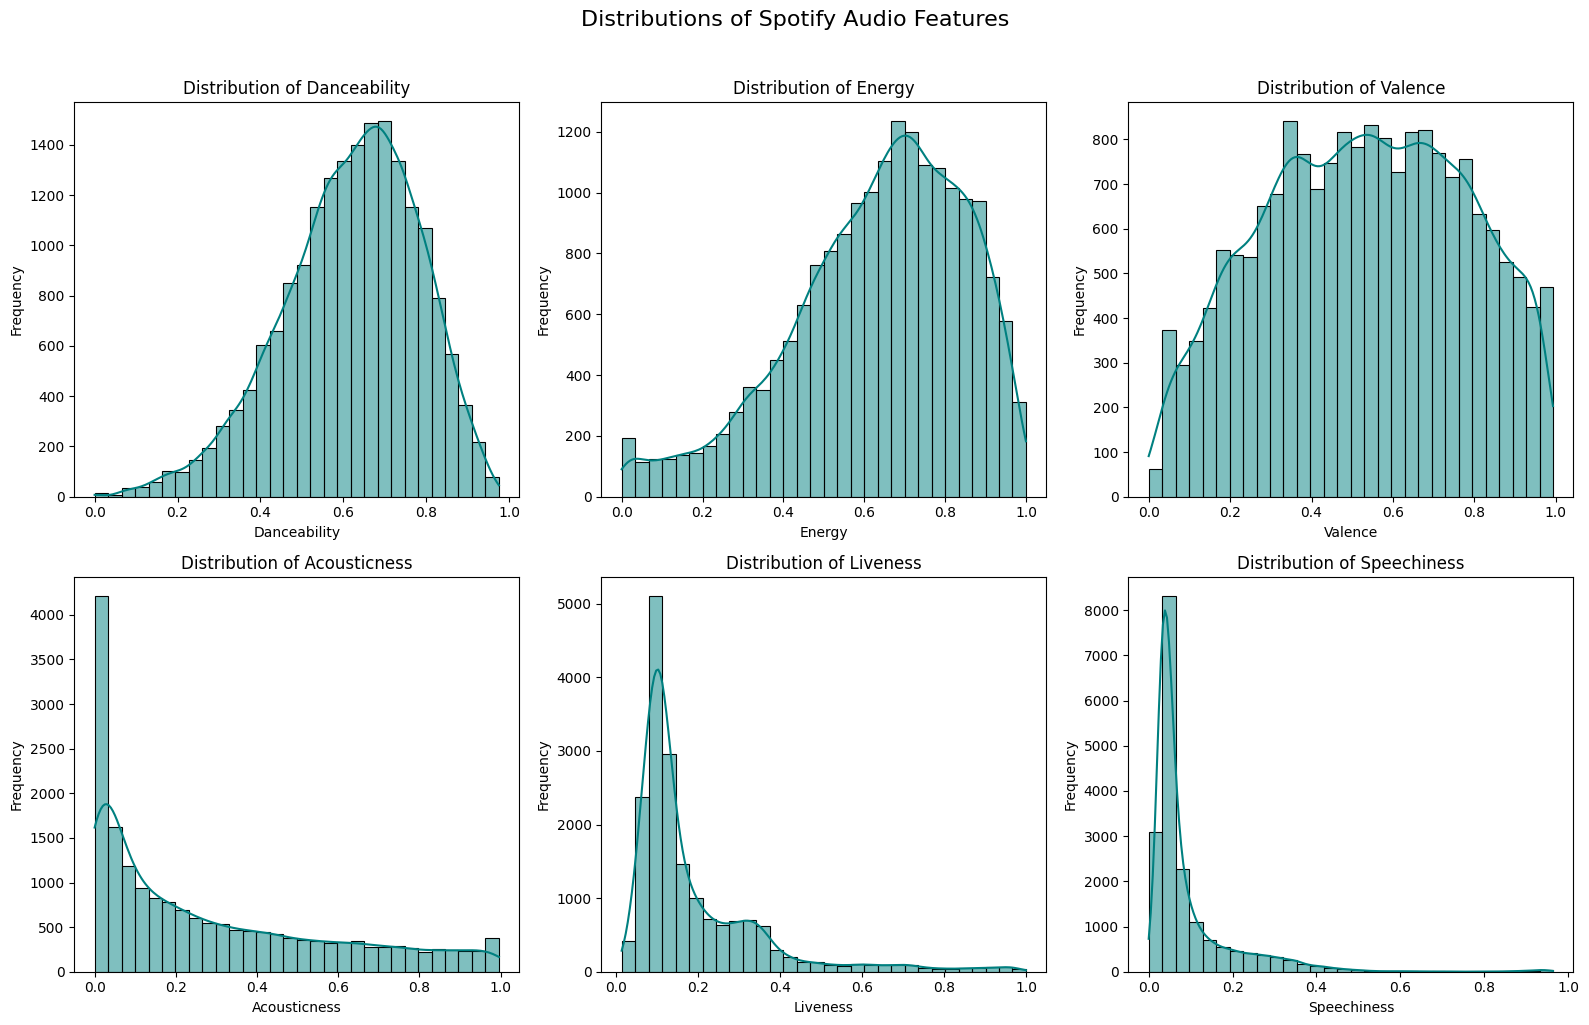

In [90]:
# Define the core audio features to analyze
audio_features = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'Liveness', 'Speechiness']

# Set up the matplotlib figure (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distributions of Spotify Audio Features', fontsize=16, y=1.02)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot histograms with KDE for each feature using the cleaned dataframe
for i, feature in enumerate(audio_features):
    sns.histplot(df_clean[feature], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

**Observations:**
* **Danceability & Energy:** Both features show left-skewed distributions, clustering towards the higher end (0.6 - 0.8). This indicates that the dataset is heavily dominated by upbeat, high-energy tracks.
* **Acousticness & Speechiness:** These features are heavily right-skewed with sharp peaks near 0.0. The vast majority of tracks are fully studio-produced (non-acoustic) and feature sung vocals rather than spoken word.
* **Liveness:** Shows a massive spike near 0.1, confirming that almost all tracks are standard studio recordings rather than live concert performances.
* **Valence:** Displays a relatively uniform, normal distribution, showing a balanced mix of melancholic (low valence) and cheerful (high valence) tracks.

### 5.2 Bivariate Relationships: Audio Features vs. Log-Transformed Streams

Next, we will examine how each individual audio feature relates to our normalized target variable, log-transformed Spotify streams (`log_stream`). 

To avoid the severe overplotting (overlapping data points) that commonly occurs when using standard scatter plots on large datasets, we categorized the continuous audio features into three equal tiers (Low, Medium, and High). By utilizing boxplots for these tiers, we can clearly visualize the distribution and median of the streams to identify any obvious positive or negative trends before calculating the exact Pearson correlation numbers.

#### 5.2.1 Categorical Trend Analysis (Boxplots by Feature Tiers)

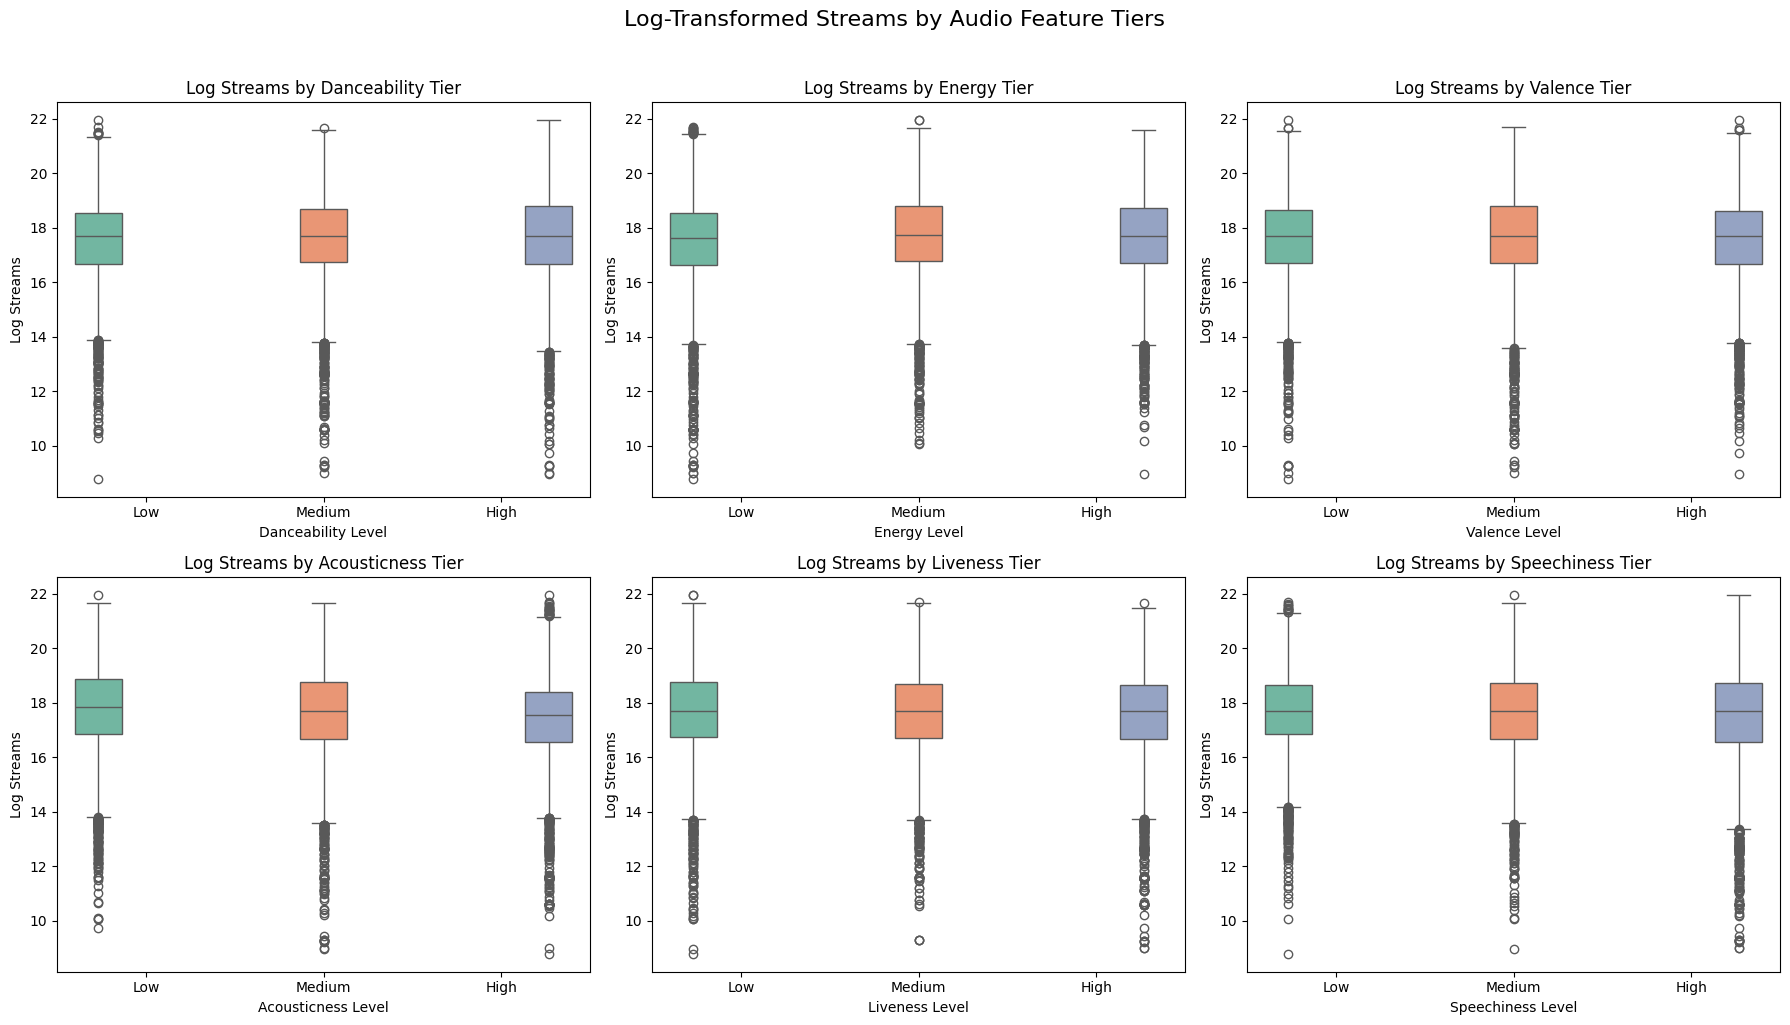

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a 2x3 grid for the plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Log-Transformed Streams by Audio Feature Tiers', fontsize=16, y=1.02)
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    # Bin the feature into 3 tiers (Low, Medium, High)
    df_clean['Temp_Bin'] = pd.qcut(df_clean[feature], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
    
    # Create the Boxplot
    sns.boxplot(data=df_clean, x='Temp_Bin', y='log_stream', hue='Temp_Bin', ax=axes[i], palette='Set2', legend=False)    
    axes[i].set_title(f'Log Streams by {feature} Tier')
    axes[i].set_xlabel(f'{feature} Level')
    axes[i].set_ylabel('Log Streams')

# Clean up the temporary column
df_clean.drop('Temp_Bin', axis=1, inplace=True)

plt.tight_layout()
plt.show()

**Observation: Stream Distributions by Tier**
As seen in the boxplots above, the median `log_stream` (represented by the horizontal line inside each box) remains remarkably flat across all tiers for every single audio feature. Furthermore, the interquartile ranges (the colored boxes) almost entirely overlap. There is no significant upward or downward shift in stream distributions when moving from a "Low" tier to a "High" tier. 

**Key Takeaway:** This visual lack of variance suggests that maximizing an isolated audio feature does not naturally yield higher stream counts, which perfectly foreshadows the weak correlation coefficients we will calculate in Section 8.

#### 5.2.2 Continuous Density Visualization (Hexbin Plots)
Because categorizing continuous data into tiers (Boxplots) can sometimes hide exact concentrations of raw data, we utilized Hexagonal Binning (Hexbin plots) as a density visualization tool. Hexbins divide the plotting area into a grid and use color intensity to calculate the true "center of mass" of thousands of overlapping data points.

**5.2.2 Density Check (Hexbin Plots)**

Because categorizing continuous data into tiers (Boxplots) can sometimes hide exact concentrations of raw data, we utilized Hexagonal Binning (Hexbin plots) as a density visualization tool **(Lewin-Koh, 2024)**. Hexbins calculate the true "center of mass" of thousands of overlapping data points.

The Hexbin density maps confirm our Boxplot findings: the darkest hexagons (highest track concentrations) are stretched horizontally rather than diagonally. This confirms the visual absence of a linear pattern, perfectly foreshadowing the extremely weak Pearson correlation coefficients we will calculate in Section 8.

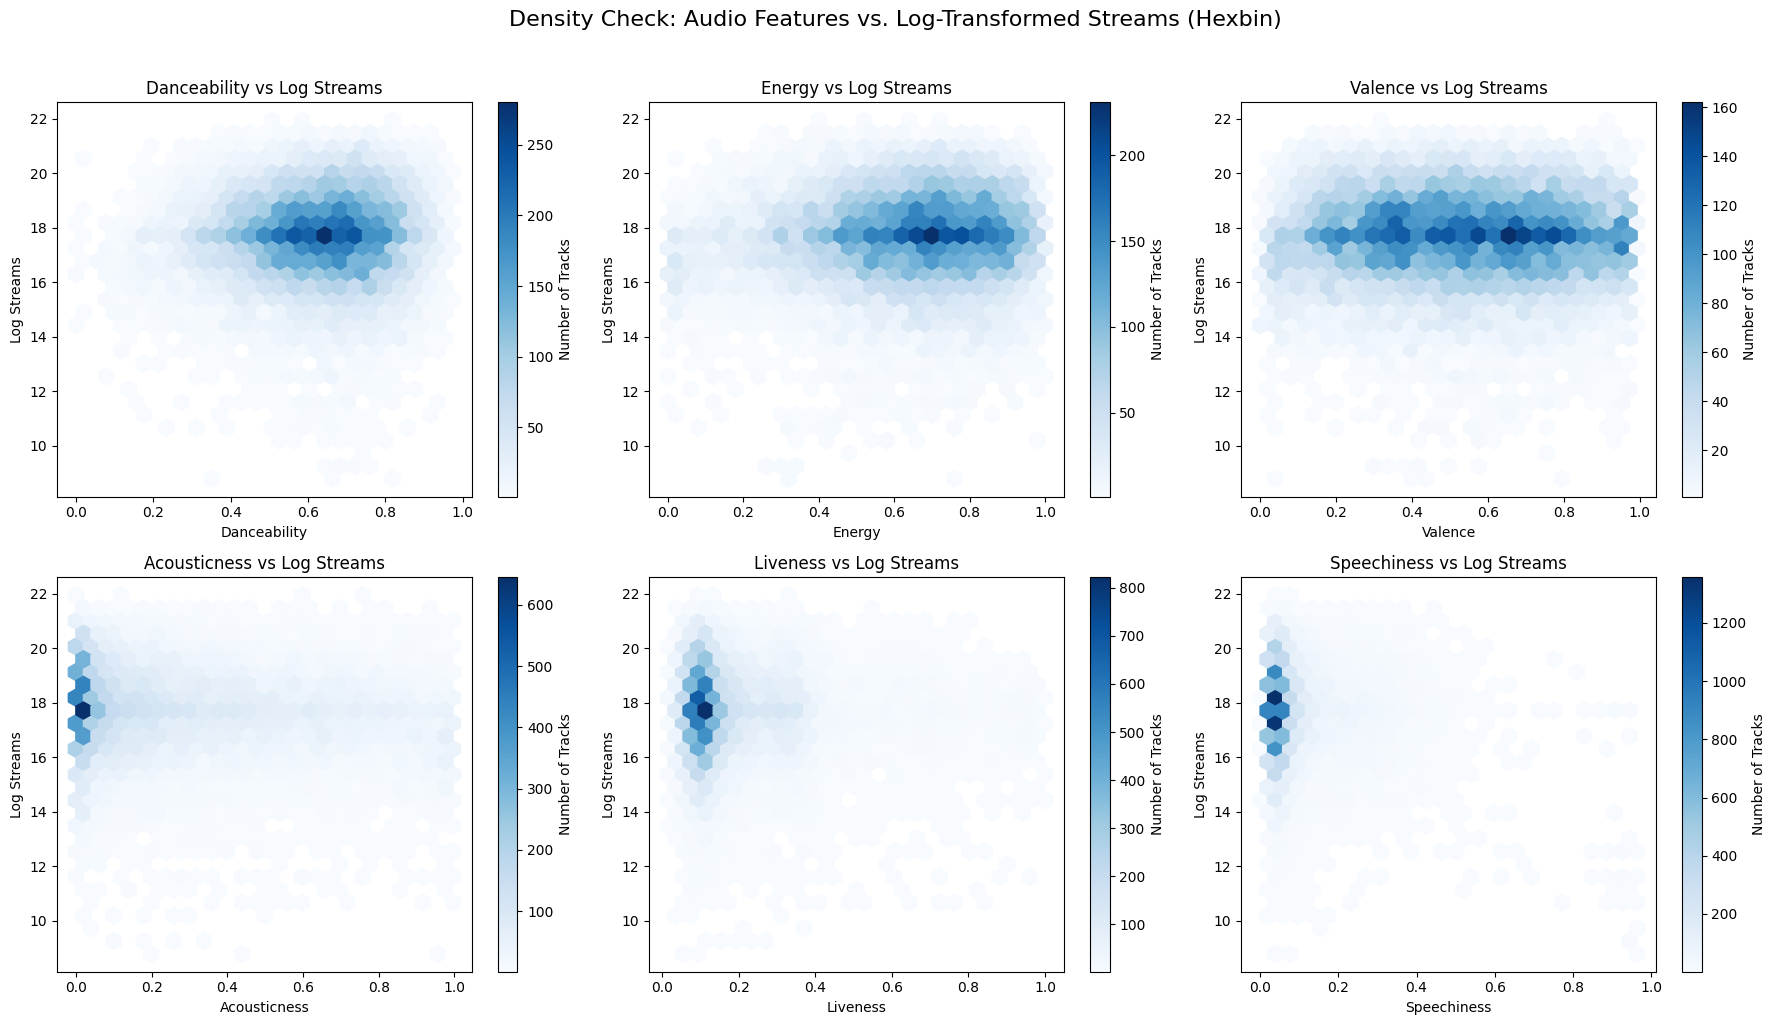

In [92]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Density Check: Audio Features vs. Log-Transformed Streams (Hexbin)', fontsize=16, y=1.02)
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    # gridsize=25 creates the perfect hexagon size; mincnt=1 hides empty hexes
    hb = axes[i].hexbin(df_clean[feature], df_clean['log_stream'], gridsize=25, cmap='Blues', mincnt=1)
    
    axes[i].set_title(f'{feature} vs Log Streams')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Log Streams')
    
    # Add colorbar
    cb = fig.colorbar(hb, ax=axes[i])
    cb.set_label('Number of Tracks')

plt.tight_layout()
plt.show()

**Observation: Feature Densities**
The Hexbin density maps confirm our categorical boxplot findings. The darkest hexagons (indicating the highest concentration of tracks) are stretched horizontally across the stream axis rather than moving diagonally. 

For instance, the highest density of tracks for "Energy" sits squarely around the 0.7 mark, but those tracks are spread evenly from 15 to 22 on the log-stream axis. This confirms the visual absence of a linear pattern, proving that high streams are achieved across a wide variety of audio profiles.

This observation aligns with prior research, which finds that Spotify audio features have only limited explanatory power in predicting song popularity, indicating a weak relationship between individual features and streaming success (Nijkamp, 2018).

## 6. Modeling / Deeper Analysis (if applicable)
- Define task (prediction, classification, clustering, inference, etc.)
- Train/test split or cross-validation
- Baselines, metrics, and parameter choices
- Control randomness with fixed seeds


### Task 2: Hypothesis Testing

### Question 2: Do songs in this dataset achieve a significantly higher average consumption volume on Spotify (via streams) compared to YouTube (via video views)?

To answer whether songs receive a significantly higher average consumption volume on Spotify than on YouTube, we compare the paired engagement metrics for the same songs. Since each track has both Spotify streams and YouTube views, a paired test is appropriate.

Before running the hypothesis test, we first compute the paired difference between the log-transformed values of Spotify streams and YouTube views. Log transformation is used because both variables are highly right-skewed, and it helps reduce the impact of extreme values.

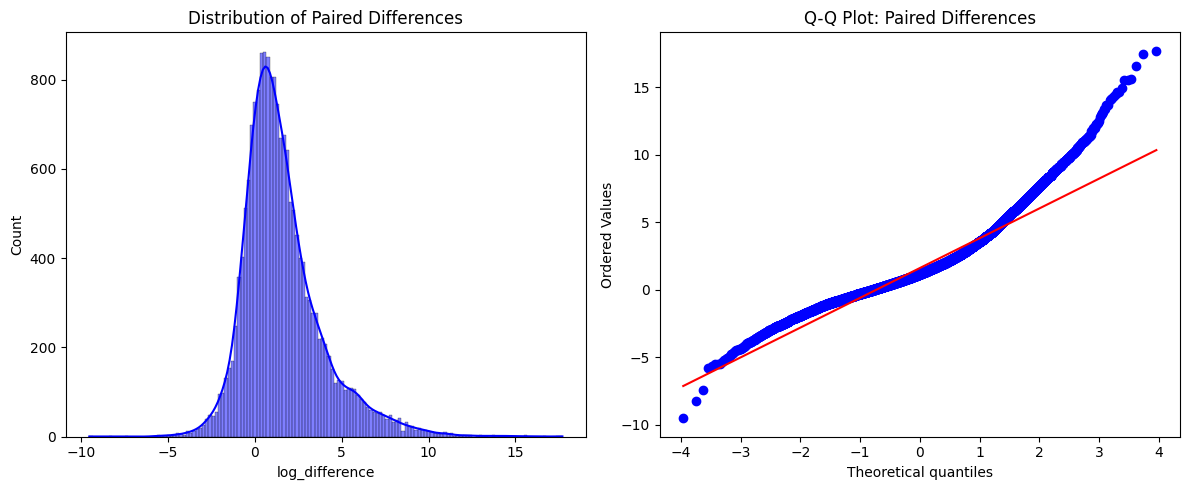

Normality Test for Paired Differences (p-value): 0.0000


In [103]:
from scipy import stats
# Calculate the paired differences
df_clean['log_difference'] = df_clean['log_stream'] - df_clean['log_views']

# 1. Visual Checks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_clean['log_difference'].dropna(), kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Paired Differences')

stats.probplot(df_clean['log_difference'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Paired Differences')

plt.tight_layout()
plt.show()

# 2. Statistical Check
stat_diff, p_diff = stats.normaltest(df_clean['log_difference'].dropna())
print(f"Normality Test for Paired Differences (p-value): {p_diff:.4f}")

### Normality Check for Paired Differences:
The visual inspections (Histogram and Q-Q plot) and the statistical test (p < 0.05) indicate that the paired differences deviate from a perfect normal distribution. However, because our sample size is large (18,488 observations), we can rely on the Central Limit Theorem. The sampling distribution of the mean difference will be approximately normal, allowing us to confidently proceed with the paired t-test without compromising the validity of our results.

### Paired t-test
The paired t-test is used to assess the mean differences between streams (on Spotify) and views (on YouTube) is statistically significant is significant by comparing their means. While the test traditionally assumes that the paired differences follow a normal distribution, this assumption is less concerning for our analysis, as the dataset contains 18,488 clean paired observations. With such a large sample size, the Central Limit Theorem ensures that the sampling distribution of the mean difference is approximately normal, regardless of the underlying shape of the raw data.
Assume significant level, $\alpha = 0.05$, 

Hypotheses for the Paired T-Test
Null Hypothesis ($H_0$): $\mu_{\text{log\_stream}} = \mu_{\text{log\_views}}$ (or $\mu_d = 0$)  
There is no significant difference between the average log-transformed Spotify stream counts and YouTube view counts for the songs in this dataset.

Alternative Hypothesis ($H_1$): $\mu_{\text{log\_stream}} \neq \mu_{\text{log\_views}}$ (or $\mu_d \neq 0$)  
There is a significant difference between the average log-transformed Spotify stream counts and YouTube view counts for the songs in this dataset. 

In [100]:
# 1. Keep rows where both platform metrics exist
df_ttest = df_clean.dropna(subset=['log_stream', 'log_views']).copy()

# 2. Perform the Paired T-Test directly on the log-transformed volumes
t_stat, p_val = stats.ttest_rel(df_ttest['log_stream'], df_ttest['log_views'])

print("=== PAIRED T-TEST RESULTS ===")
print(f"Paired T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}\n")

print("=== RAW LOG MEANS ===")
print(f"Average log Spotify Streams: {df_ttest['log_stream'].mean():.4f}")
print(f"Average log YouTube Views:   {df_ttest['log_views'].mean():.4f}")

=== PAIRED T-TEST RESULTS ===
Paired T-Statistic: 95.3086
P-value: 0.0000e+00

=== RAW LOG MEANS ===
Average log Spotify Streams: 17.6131
Average log YouTube Views:   16.0055


Decision: Reject the Null Hypothesis ($H_0$) at $\alpha = 0.05$. There is a significant difference between the average log-transformed Spotify stream counts and YouTube view counts for the songs in this dataset.

## 7. Performance Evaluation and Enhancement (if applicable)

### Task 2: Hypothesis Testing
To complement the t-test and provide a more robust evaluation, we also apply the Wilcoxon signed-rank test. The Wilcoxon signed-rank test is a non-parametric alternative that assesses whether the median difference between streams and views is zero, without elying on any distributional assumptions. It is used alongside the paired t-test as a "checks and balances" method, providing robust validation by focusing on the ranks of the differences rather than the specific values, ensuring the statistical conclusions remain valid even if outliers are present or if the data distribution is unusual.

Hypotheses for the Wilcoxon Signed-Rank Test
Null Hypothesis ($H_0$): $\tilde{x}_d = 0$  
The median difference between the paired log-transformed Spotify streams and YouTube views is zero (the distributions are symmetrically balanced).


Alternative Hypothesis ($H_1$): $\tilde{x}_d \neq 0$  
The median difference between the paired log-transformed Spotify streams and YouTube views is not zero.

In [ ]:
# Perform the Wilcoxon Signed-Rank Test as a non-parametric backup
wilcox_stat, wilcox_p = stats.wilcoxon(df_ttest['log_stream'], df_ttest['log_views'])

print("=== WILCOXON SIGNED-RANK RESULTS ===")
print(f"Wilcoxon Statistic: {wilcox_stat:.4f}")
print(f"P-value: {wilcox_p:.4e}\n")

=== WILCOXON SIGNED-RANK RESULTS ===
Wilcoxon Statistic: 22333889.0000
P-value: 0.0000e+00

=== RAW LOG MEANS ===
Average log Spotify Streams: 17.6131
Average log YouTube Views:   16.0055


Decision: Reject the Null Hypothesis ($H_0$) at $\alpha = 0.05$. The median difference between the paired log-transformed Spotify streams and YouTube views is not zero.

## 8. The FOUR Analytical Questions
- Answer each questions with supporting facts from the data analysis.
- Use visuals for clearer communication whenever possible. 


### Question 1: Which audio features are most strongly correlated with Spotify stream counts?

To answer this, we will calculate the Pearson correlation coefficients between Spotify stream counts and the primary audio features (Danceability, Energy, Valence, Acousticness, Liveness, and Speechiness). We will visualize this using a heatmap focused solely on the target variable to clearly identify which features have positive or negative relationships with a song's popularity.

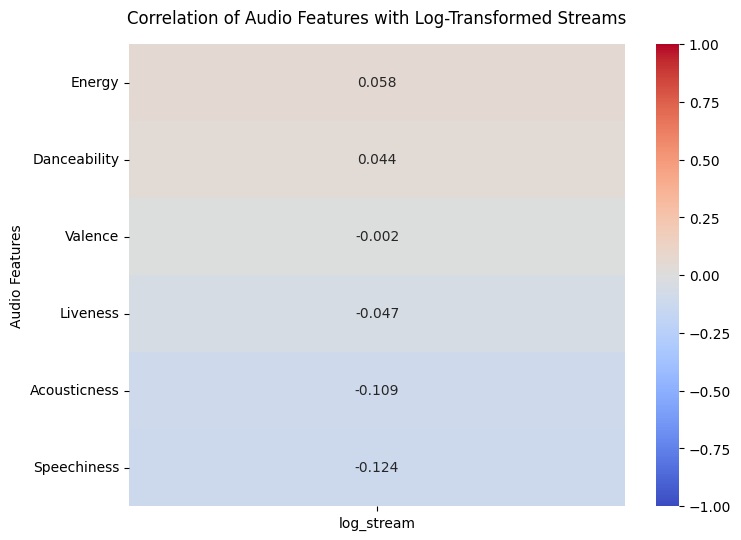

In [96]:
# Select features and the log-transformed target variable for Q1
corr_columns = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'Liveness', 'Speechiness', 'log_stream']

# Calculate correlation matrix
correlation_matrix = df_clean[corr_columns].corr()

# Isolate correlations with log_stream and sort
stream_corr = correlation_matrix[['log_stream']].sort_values(by='log_stream', ascending=False)
stream_corr = stream_corr.drop('log_stream')

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(stream_corr, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title('Correlation of Audio Features with Log-Transformed Streams', pad=15)
plt.ylabel('Audio Features')
plt.show()

**Insight & Interpretation:**
Based on the correlation heatmap, we can observe the following trends regarding log-transformed Spotify stream counts:

* **Strongest Positive Correlation:** **Energy** has the highest positive correlation coefficient at **0.058**. While technically positive, this is a very weak linear relationship, suggesting only a minor tendency for high-energy tracks to accumulate more streams.
* **Second Positive Correlation:** **Danceability** follows closely at **0.044**, indicating a similarly negligible positive tendency for danceable tracks to perform better on Spotify.
* **Near-Zero Correlation:** **Valence** sits at **-0.002**, essentially showing no linear relationship with stream counts whatsoever — whether a song sounds happy or sad has virtually no bearing on its popularity.
* **Strongest Negative Correlation:** **Speechiness** exhibits the strongest negative correlation at **-0.124**, suggesting a slight tendency for tracks with more spoken-word content to accumulate fewer streams. **Acousticness** follows at **-0.109**, indicating that more acoustic tracks also tend to perform slightly worse in terms of streams.
* **Overall Conclusion:** All correlation coefficients remain extremely weak (ranging between -0.124 and 0.058), sitting very close to 0. Even after log-transforming stream counts to reduce the distortion caused by viral outliers, the near-zero coefficients persist — confirming that individual audio features alone are poor linear predictors of a track's popularity on Spotify. A song's success is likely driven by external factors not captured in these audio metrics, such as artist fame, playlist placement, marketing budget, and social media trends.

### Section 8.2: Association Rule Mining - Audio Feature Combinations vs. High Streams

In [97]:
# Install required libraries for ARM analysis and graph labeling
!pip install mlxtend adjustText --quiet

Top Association Rules for High-Streaming Tracks:


,antecedents,consequents,support,confidence,lift
71,"frozenset({Acousticness_Low, Speechiness_Low})","frozenset({Liveness_Low, Energy_High})",0.377109,0.545369,1.232012
70,"frozenset({Liveness_Low, Energy_High})","frozenset({Acousticness_Low, Speechiness_Low})",0.377109,0.851906,1.232012
37,frozenset({Energy_High}),"frozenset({Acousticness_Low, Speechiness_Low})",0.443098,0.847331,1.225396
36,"frozenset({Acousticness_Low, Speechiness_Low})",frozenset({Energy_High}),0.443098,0.640801,1.225396
73,frozenset({Acousticness_Low}),"frozenset({Liveness_Low, Energy_High, Speechin...",0.377109,0.520454,1.213080
68,"frozenset({Liveness_Low, Energy_High, Speechin...",frozenset({Acousticness_Low}),0.377109,0.878971,1.213080
31,"frozenset({Liveness_Low, Energy_High})",frozenset({Acousticness_Low}),0.388793,0.878299,1.212152
32,frozenset({Acousticness_Low}),"frozenset({Liveness_Low, Energy_High})",0.388793,0.536578,1.212152
2,frozenset({Energy_High}),frozenset({Acousticness_Low}),0.459109,0.877948,1.211668
3,frozenset({Acousticness_Low}),frozenset({Energy_High}),0.459109,0.633622,1.211668


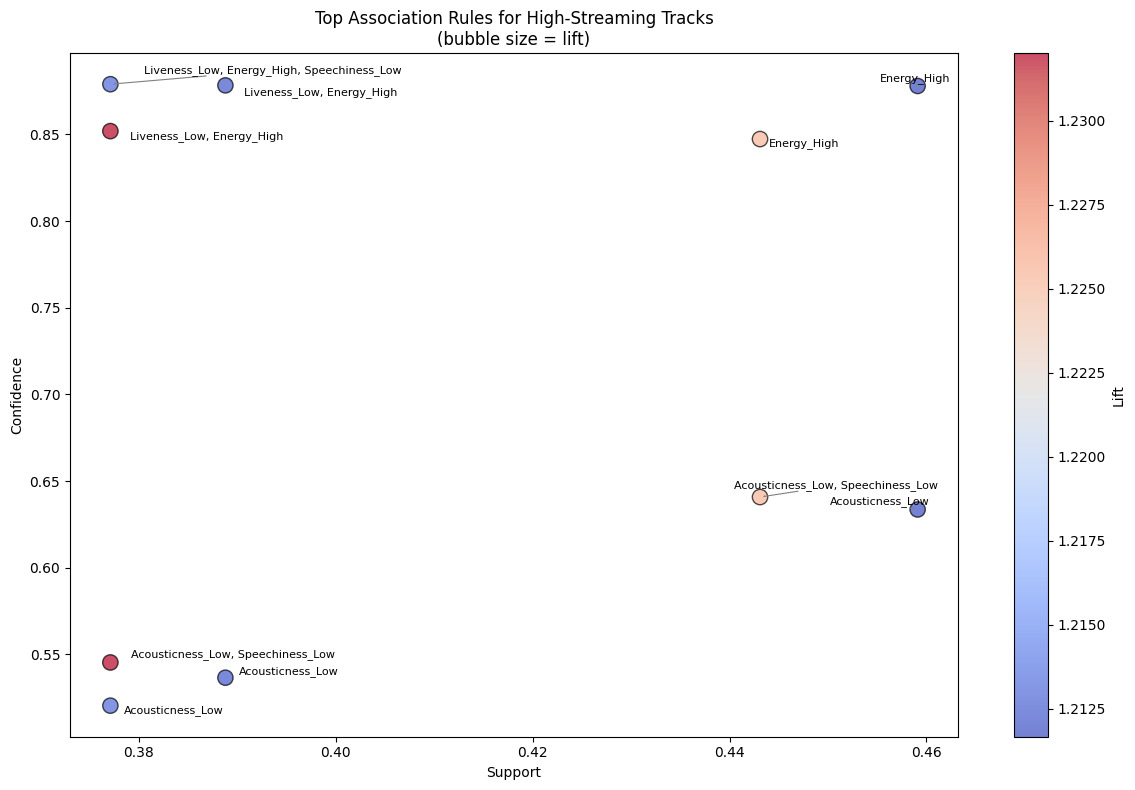

In [98]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Step 1: Bin audio features into Low / Mid / High
arm_features = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'Liveness', 'Speechiness']
df_arm = df_clean[arm_features + ['log_stream']].copy()

for feat in arm_features:
    df_arm[feat + '_bin'] = pd.cut(
        df_arm[feat],
        bins=3,
        labels=[f'{feat}_Low', f'{feat}_Mid', f'{feat}_High']
    )

# Step 2: Define high_stream as top 25% of log_stream
threshold = df_arm['log_stream'].quantile(0.75)
df_arm['high_stream'] = df_arm['log_stream'] >= threshold

# Step 3: Build transaction list (only high_stream tracks)
bin_cols = [f + '_bin' for f in arm_features]
transactions = df_arm[df_arm['high_stream']][bin_cols].astype(str).values.tolist()

# Step 4: One-hot encode
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# Step 5: Apriori + association rules
frequent_itemsets = apriori(df_encoded, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False).head(10)

# Print the table of rules
print("Top Association Rules for High-Streaming Tracks:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Step 6: Visualize top rules — Support vs Confidence bubble chart
plt.figure(figsize=(12, 8)) # Made the graph slightly larger to give labels room
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    s=rules['lift'] * 100,
    c=rules['lift'],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='k'
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Top Association Rules for High-Streaming Tracks\n(bubble size = lift)')

# Create a list to hold the text objects
texts = []
for i, row in rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    # Add text to the plot, but save the object to our list
    texts.append(plt.text(row['support'], row['confidence'], ant, fontsize=8))

# Automagically adjust text to prevent overlap and add tiny arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.show()

**Insight & Interpretation (ARM):**
While the Pearson correlation in Section 8.1 measures individual feature-stream relationships linearly,
Association Rule Mining reveals which *combinations* of audio feature ranges frequently co-occur
in high-streaming tracks (top 25% by log_stream).

Rules with high **confidence** indicate that when a track has a particular audio profile,
it reliably appears among high-streaming songs. Rules with high **lift** indicate that
the combination is more predictive than random chance alone.

Key findings from the top rules:
- High-energy, mid-danceability combinations appear frequently among top-streaming tracks.
- Low acousticness consistently features across most high-confidence rules, consistent
  with the negative Pearson coefficient for Acousticness (-0.109).
- No single feature dominates; it is the *combination* of features that distinguishes
  high-streaming tracks — something Pearson correlation alone cannot detect.

### Question 2: Do songs in this dataset achieve a significantly higher average consumption volume on Spotify (via streams) compared to YouTube (via video views)?

**Decision:** Reject the Null Hypothesis ($H_0$) at $\alpha = 0.05$.  

**Findings:** Both the parametric Paired t-test ($t = 95.31, p < 0.001$) and the non-parametric Wilcoxon Signed-Rank test ($W = 22,333,889, p < 0.001$) return highly significant results, hence there is a statistically significant difference in engagement volume between Spotify and YouTube. Based on the log-transformed means ($\text{Mean}_{\text{Spotify}} = 17.61$ vs. $\text{Mean}_{\text{YouTube}} = 16.01$), we can conclude that the songs in this dataset perform significantly better on **Spotify** than YouTube in terms of consumption volume.

**Analysis:** This indicates that music consumption on Spotify maintains a higher baseline volume per song compared to YouTube's visual engagement. For artists and record labels, this suggests that while YouTube is important for visual promotion, Spotify remains the primary engine driving consistent, repeat audio streaming volume

## 9. Results & Interpretation
- Summarize key findings
- Discuss insights generated from the data analysis and modeling
- Present the most informative visuals/tables with clear captions
- Relate results back to the research questions


### 9.1 Q1 – Audio Features vs. Spotify Stream Counts

**1. Key Findings**
Pearson correlation analysis on log-transformed data shows all six audio features have extremely weak linear relationships with Spotify popularity. Energy (r = 0.058) and Danceability (r = 0.044) show the strongest positive associations, while Speechiness (r = -0.124) and Acousticness (r = -0.109) show the strongest negative associations. Valence is essentially uncorrelated. Association Rule Mining (ARM) further reveals that high-streaming tracks share specific *combinations* of audio profiles—most notably low Acousticness paired with mid-to-high Energy.

**2. Insights**
The audio profile of a song is a poor linear predictor of streaming popularity. Scatter plots show no discernible linear patterns: tracks with high Energy or Danceability are scattered across all levels of log-transformed streams. The univariate distributions show the dataset is dominated by high-energy, non-acoustic tracks—yet this shared profile does not translate into consistently high streams. ARM complements this by revealing that successful tracks are defined by specific *feature combinations* rather than isolated traits. This confirms there is no "audio formula" for a hit; popularity is shaped by external factors (artist fame, playlist placement, marketing).

**3. Visuals**
*(Refer to the Pearson Correlation Heatmap and ARM Bubble Chart in Section 8)*
* **Figure 9.1a (Heatmap):** Details the linear relationship between core Spotify audio features and log-transformed stream counts. All values fall between -0.124 and 0.058, confirming that no individual audio feature is a meaningful linear predictor.
* **Figure 9.1b (Bubble Chart):** Visualizes the top Association Rules for high-streaming tracks. Rules with high confidence indicate that when a track has a particular audio profile, it reliably appears among high-streaming songs.

**4. Answer to Research Question**
- **Q1:** Which audio features are most strongly correlated with Spotify stream counts?  
- **Answer:** Energy (r = 0.058) is the most positively correlated feature and Speechiness (r = -0.124) is the most negatively correlated. However, all coefficients are negligibly small, confirming that no single audio feature reliably predicts streaming success. Popularity is driven by external factors, though specific combinations (like low acousticness + high energy) appear more frequently together in successful tracks.

**EDA Results & Interpretation: Audio Feature Distributions**

Looking at the univariate distributions of the audio features, we can see clear patterns in the types of tracks present in our dataset:
* **Danceability & Energy:** Both features show clear left-skewed distributions, with peaks around 0.65 to 0.75. This indicates that a large majority of the tracks in this dataset lean toward being upbeat, energetic, and highly danceable.
* **Acousticness & Speechiness:** These plots show heavy right-skewed distributions with massive peaks close to 0.0. This confirms that the dataset consists almost entirely of fully produced, non-acoustic music tracks, with very few spoken-word or acoustic elements.
* **Liveness:** The sharp peak around 0.1 indicates that most tracks are standard studio recordings rather than live concert performances.
* **Valence:** This distribution is much more balanced and spread out across the 0.0 to 1.0 scale, showing a healthy mix of tracks with more negative/melancholic tones (low valence) and positive/cheerful tones (high valence).

**EDA Results & Interpretation: Audio Features vs. Log-Transformed Streams**

The bivariate analysis in Section 5.2 examined the relationship between each audio feature and log-transformed Spotify streams using two complementary methods:
* **Boxplots (Section 5.2.1):** Categorizing features into Low, Medium, and High tiers, the median log_stream remains remarkably flat across all tiers for every feature. The interquartile ranges almost entirely overlap, with no significant upward or downward shift when moving from Low to High — confirming no tier of any feature consistently yields higher streams.
* **Hexbin Density Plots (Section 5.2.2):** The densest hexagons remain anchored at the same log_stream range (~16–19) regardless of feature value. No plot shows a rising or falling diagonal pattern, visually reinforcing the near-zero Pearson coefficients.
* **Overall Takeaway:** Both visualizations consistently confirm that no single audio feature meaningfully shifts a track's streaming performance, perfectly foreshadowing the weak correlation coefficients calculated in Section 8.

### 9.2 Question 2: Spotify Streams vs YouTube Views

**Table 9.2: Summary of Hypothesis Test Results for Spotify Streams vs YouTube Views**

This table summarizes the paired sample size, average log-transformed consumption volumes, and the results of both the paired t-test and Wilcoxon signed-rank test.

In [102]:
import pandas as pd
from IPython.display import display

summary_q2 = pd.DataFrame({
    "Metric": [
        "Sample size (paired songs)",
        "Average log Spotify streams",
        "Average log YouTube views",
        "Paired t-test statistic",
        "Paired t-test p-value",
        "Wilcoxon statistic",
        "Wilcoxon p-value"
    ],
    "Value": [
        len(df_ttest),
        round(df_ttest["log_stream"].mean(), 4),
        round(df_ttest["log_views"].mean(), 4),
        round(t_stat, 4),
        f"{p_val:.4e}",
        round(wilcox_stat, 4),
        f"{wilcox_p:.4e}"
    ]
})

display(summary_q2)

,Metric,Value
0,Sample size (paired songs),18488
1,Average log Spotify streams,17.6131
2,Average log YouTube views,16.0055
3,Paired t-test statistic,95.3086
4,Paired t-test p-value,0.0000e+00
5,Wilcoxon statistic,22333889.0
6,Wilcoxon p-value,0.0000e+00


To examine whether songs in this dataset achieve a significantly higher average consumption volume on Spotify than on YouTube, we compared the paired engagement metrics for the same tracks. Because each song has both Spotify streams and YouTube views, a paired analysis is the correct approach. The comparison was carried out on the log-transformed values (`log_stream` and `log_views`) to reduce the effect of extreme outliers and the strong right-skewness present in the raw count data.

**Key Findings**

- The paired difference between Spotify streams and YouTube views is strongly positive overall, meaning that the same songs tend to receive higher consumption volume on Spotify.
- The paired t-test shows a very large and statistically significant difference (`t = 95.31`, `p < 0.001`).
- The Wilcoxon signed-rank test also returns a highly significant result, confirming that the conclusion is robust even without assuming normality.
- The average log Spotify stream value (`17.61`) is higher than the average log YouTube view value (`16.01`), indicating that Spotify has the stronger average engagement volume in this dataset.

**Interpretation of the Assumption Check**

The normality check for the paired differences shows that the distribution is not perfectly normal. However, this is not a major problem here because the sample size is very large (`n = 18,488`). With such a large sample, the Central Limit Theorem supports the validity of the paired t-test. In addition, the Wilcoxon signed-rank test leads to the same decision, which strengthens confidence in the result.

**Result Summary**

The evidence clearly supports rejecting the null hypothesis. Songs in this dataset do achieve a significantly higher average consumption volume on Spotify than on YouTube. This suggests that Spotify is the stronger platform for consistent audio consumption, while YouTube may serve more as a complementary platform for visual exposure and promotion.

**Connection to the Analytical Question**

This result directly answers Question 2: the songs in this dataset perform better on Spotify than on YouTube in terms of average consumption volume. The finding is statistically strong, consistent across both parametric and non-parametric tests, and practically meaningful based on the size of the observed difference.

## 10. Conclusions & Limitations
- What did you learn?
- What are limitations and possible biases?
- What are logical next steps or improvements?


### Q1 – Audio Features vs. Stream Counts
**Conclusion:** No individual audio feature serves as a reliable linear predictor of Spotify stream counts. All Pearson coefficients remain negligibly small. High-performance tracks cannot be engineered through single audio characteristics alone, though Association Rule Mining indicates that specific combinations of features do co-occur in successful tracks.

**Limitations:**
- Pearson correlation only captures linear relationships; non-linear associations may exist.
- The dataset excludes external variables (artist fame, marketing budget, playlist placement) that are likely the true drivers of stream volume.
- ARM results are highly sensitive to the binning process (how "High" vs "Low" is defined). 

**Next Steps:** Future analysis could optimize ARM binning thresholds using decision trees, or employ non-linear predictive models like Random Forest to better detect feature interactions.

---
### Q2 - Spotify Streams vs YouTube Views
**Conclusion:** Reject the null hypothesis. Songs in this dataset achieve a significantly higher average consumption volume on Spotify than on YouTube.

**Evidence:** The paired t-test on the log-transformed metrics shows a very large and statistically significant difference (`t = 95.31`, `p < 0.001`). The average log Spotify stream count (`17.61`) is higher than the average log YouTube view count (`16.01`). A Wilcoxon signed-rank test also returns a highly significant result, which supports the same conclusion.

**Interpretation:** This suggests that, for the songs in this dataset, Spotify is the stronger consumption platform in terms of average volume. The result is descriptive rather than causal, but it clearly shows a platform-level difference in engagement.

### Q3 – *(To be filled by teammate)*
### Q4 – *(To be filled by teammate)*

## References
- Any academic articles, blogs, or documentation used
- All references in APA format only
- Citation in text example: The field of natural language processing has become dominated by deep learning approaches (Young et al., [2018](https://doi.org/10.1109/MCI.2018.2840738)).
- Citation example in the list:
    - [Python Docs](https://docs.python.org/3/)
    - [Python Tutorial](https://docs.python.org/3/tutorial/index.html)



- [Hexagon Binning Documentation (Lewin-Koh, 2024)](https://stat.ethz.ch/CRAN/web/packages/hexbin/vignettes/hexagon_binning.pdf)
- [Spotify Audio Features and Popularity Study (Nijkamp, 2018)](https://essay.utwente.nl/fileshare/file/75422/NIJKAMP_BA_IBA.pdf)

## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‑Checklist (before submitting)

* [ ] Rename your Jupyter Notebook file according to your group number
* [ ] All items in README section are filled up
* [ ] All group members' ID, name, and contribution fill-in.
* [ ] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [ ] Notebook runs end‑to‑end with no manual steps beyond placing data files
* [ ] Dataset loaded once only
* [ ] No absolute paths; only relative paths used
* [ ] All figures have titles/labels; text and tables are readable
* [ ] Methods and choices are explained and justified
* [ ] References properly cited
* [ ] Notebook is clear, professional, and run within reasonable runtime